# Proof-of-Concept 4-Parameter Model K-Fold Cross-Validation

This notebook uses K-Fold Cross Validation on a small proof-of-concept emulator that predicts the **binned kSZ angular power spectrum ($D_\ell$)** using 4 reionization params ($z_{mean}$, $\alpha$, $k_b$, $b_0$).

In [5]:
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
plt.rc("figure", figsize=(6, 4), dpi=200)

from reionemu import FourParamEmulator
from reionemu import DataLoaderConfig
from reionemu import FitConfig, KFoldConfig, kfold_cross_validate

## Condensed HDF5 Path
The condensed v6 simulation dataset is constructed with: $Y = \ln(D_\ell)$

In [6]:
H5_PATH = Path("../data/processed/condensed_v6.h5").resolve()

## Define Model | Optimizer | Configs

In [7]:
def model_builder() -> torch.nn.Module:
    return FourParamEmulator()

def optimizer_builder(model: torch.nn.Module) -> torch.optim.Optimizer:
    return torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

loss_fn = torch.nn.MSELoss()

dlcfg = DataLoaderConfig(
    batch_size=32,
    seed=42,
    shuffle_train=True,
    normalize_X=True,
    normalize_Y=False
)

fitcfg = FitConfig(
    epochs=200,
    device="mps",
    early_stopping_patience=25,
    gradient_clipping=None
)

kcfg = KFoldConfig(
    k=5,
    seed=42,
    return_histories=True
)

## Run K-Fold Cross Validation

In [8]:
result = kfold_cross_validate(
    H5_PATH,
    model_builder=model_builder,
    optimizer_builder=optimizer_builder,
    loss_fn=loss_fn,
    kfold_config=kcfg,
    dl_config=dlcfg,
    fit_config=fitcfg
)


=== Fold 1/5 | train=800 val=200 ===
Epoch 001: train=0.279642, val=0.249522
Epoch 002: train=0.218387, val=0.184966
Epoch 003: train=0.146475, val=0.106261
Epoch 004: train=0.070332, val=0.041347
Epoch 005: train=0.028074, val=0.021919
Epoch 006: train=0.017777, val=0.017300
Epoch 007: train=0.014836, val=0.015321
Epoch 008: train=0.013143, val=0.013797
Epoch 009: train=0.011980, val=0.012837
Epoch 010: train=0.011102, val=0.012235
Epoch 011: train=0.010533, val=0.011705
Epoch 012: train=0.010063, val=0.010914
Epoch 013: train=0.009635, val=0.010560
Epoch 014: train=0.009257, val=0.010260
Epoch 015: train=0.008869, val=0.009879
Epoch 016: train=0.008633, val=0.009790
Epoch 017: train=0.008327, val=0.009448
Epoch 018: train=0.008266, val=0.009273
Epoch 019: train=0.008036, val=0.009331
Epoch 020: train=0.007805, val=0.008998
Epoch 021: train=0.007668, val=0.008991
Epoch 022: train=0.007617, val=0.008979
Epoch 023: train=0.007422, val=0.008779
Epoch 024: train=0.007260, val=0.008706
Ep

## K-Fold CV Results

In [9]:
result.keys()
print(f"Min Validation Loss Per Fold: {result['fold_best_val']}")
print(f"Mean Validation Loss: {result['mean_best_val']}")
print(f"STD Validation Loss: {result['std_best_val']}")

Min Validation Loss Per Fold: [0.004161086864769459, 0.003871196499094367, 0.003609083201736212, 0.0035211985278874635, 0.003881575744599104]
Mean Validation Loss: 0.003808828167617321
STD Validation Loss: 0.0002529313491311653


## Plot Learning Curves Per Fold

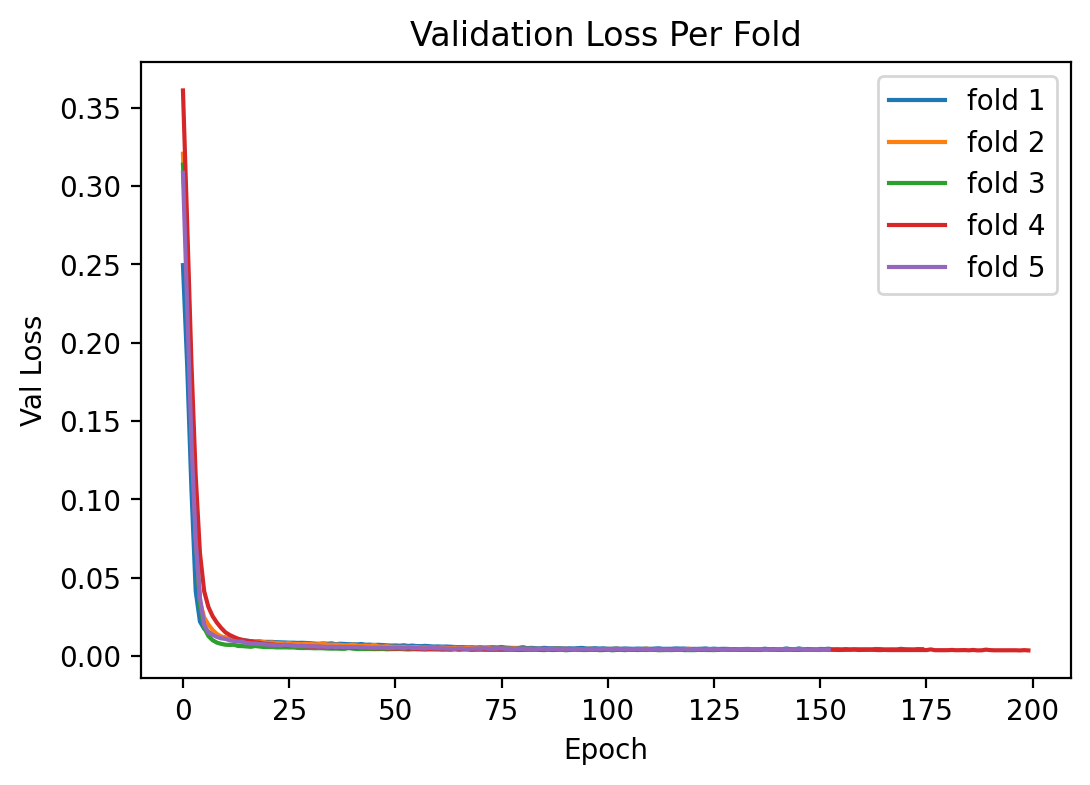

In [10]:
histories = result["histories"]

plt.figure()
for i, h in enumerate(histories):
    plt.plot(h["val_loss"], label=f"fold {i+1}")
plt.xlabel("Epoch")
plt.ylabel("Val Loss")
plt.title("Validation Loss Per Fold")
plt.legend()
plt.show()

## Best Validation Loss Per Fold

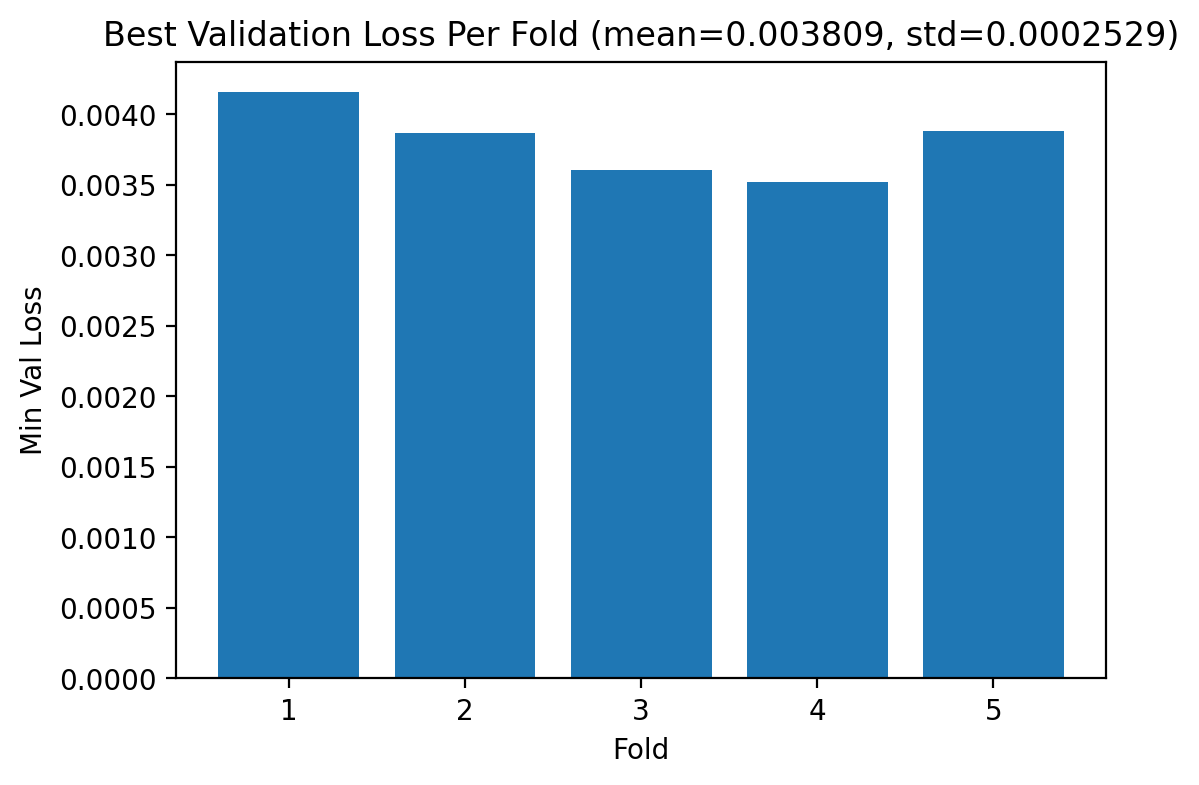

In [11]:
best_vals = np.array(result["fold_best_val"], dtype=float)
plt.figure()
plt.bar(np.arange(1, len(best_vals)+1), best_vals)
plt.xlabel("Fold")
plt.ylabel("Min Val Loss")
plt.title(f"Best Validation Loss Per Fold (mean={result['mean_best_val']:.4g}, std={result['std_best_val']:.4g})")
plt.show()